In [11]:
import pandas as pd
import numpy as np
import os
os.chdir(r'D:\HKUST\5054_Statistical_Machine_Learning\Assignments\HW4\MNIST\MNIST')
import warnings
warnings.filterwarnings('ignore')

# Load data
train_df = pd.read_csv('train_resized.csv')
test_df = pd.read_csv('test_resized.csv')
train_df.head()

# Separate labels and pixels
y_train_full = train_df.iloc[:, 0].values.astype(int)  
y_test_full = test_df.iloc[:, 0].values.astype(int) 
X_train_full = train_df.iloc[:, 1:].values  
X_test_full = test_df.iloc[:, 1:].values      

Training samples: 6026
Test samples: 2462
Best C: 10
Best CV accuracy: 0.9932
Training time: 4.24 seconds

Test accuracy: 0.9907
Test misclassification error: 0.0093


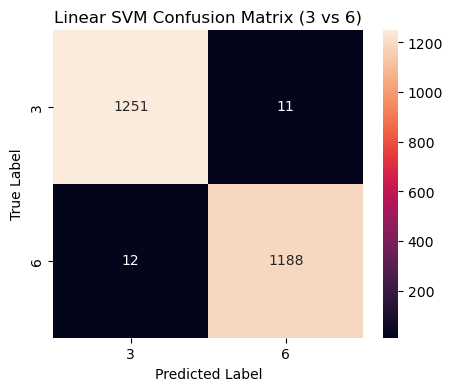

In [12]:
# P3_Q1
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import time
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Select only digits 3 and 6
digits = [3, 6]

mask_train = np.isin(y_train_full, digits)
X_train = X_train_full[mask_train]
y_train = y_train_full[mask_train]

mask_test = np.isin(y_test_full, digits)
X_test = X_test_full[mask_test]
y_test = y_test_full[mask_test]

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

# SVM requires feature scaling, sensitive to feature scales
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5-fold stratified CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=3042)

# Parameter grid for linear SVM
param_grid = {'C': [1, 10, 100, 1000]}

# Linear SVM
svm_linear = SVC(kernel='linear', random_state=3042)

# Grid search
start_time = time.time()
grid_search = GridSearchCV(svm_linear, param_grid, cv=skf, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
train_time = time.time() - start_time

best_C = grid_search.best_params_['C']
best_acc = grid_search.best_score_
print(f"Best C: {best_C}")
print(f"Best CV accuracy: {best_acc:.4f}")
print(f"Training time: {train_time:.2f} seconds") 

# Predict on test set
y_pred = grid_search.predict(X_test_scaled)

# Test accuracy and error
test_acc = accuracy_score(y_test, y_pred)
test_error = 1 - test_acc

print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test misclassification error: {test_error:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=digits, yticklabels=digits)
plt.title('Linear SVM Confusion Matrix (3 vs 6)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Best C: 10
Best gamma: 0.001
Best CV accuracy: 0.9967
Training time: 48.00 seconds

Test accuracy: 0.9963
Test misclassification error: 0.0037


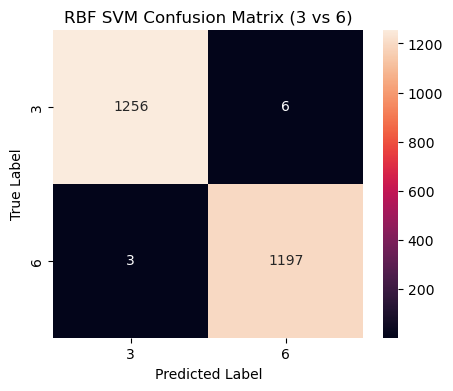

In [16]:
# P3_Q2

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

param_grid_rbf = {
    'C': [1, 10, 100, 1000],
    'gamma': [0.001, 0.01, 0.1, 1]  # typical range for 144-dim data
}

# 5-fold stratified CV
svm_rbf = SVC(kernel='rbf', random_state=3042)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=3042)

start_time = time.time()
grid_search_rbf = GridSearchCV(
    svm_rbf, param_grid_rbf, cv=skf, scoring='accuracy', n_jobs=-1
)
grid_search_rbf.fit(X_train_scaled, y_train)
train_time_rbf = time.time() - start_time

# Extract best parameters and CV accuracy
best_C_rbf = grid_search_rbf.best_params_['C']
best_gamma_rbf = grid_search_rbf.best_params_['gamma']
best_cv_acc_rbf = grid_search_rbf.best_score_

print(f"Best C: {best_C_rbf}")
print(f"Best gamma: {best_gamma_rbf}")
print(f"Best CV accuracy: {best_cv_acc_rbf:.4f}")
print(f"Training time: {train_time_rbf:.2f} seconds")

# Predict on test set
y_pred_rbf = grid_search_rbf.predict(X_test_scaled)
test_acc_rbf = accuracy_score(y_test, y_pred_rbf)
test_error_rbf = 1 - test_acc_rbf

print(f"\nTest accuracy: {test_acc_rbf:.4f}")
print(f"Test misclassification error: {test_error_rbf:.4f}")

# Confusion Matrix
cm_rbf = confusion_matrix(y_test, y_pred_rbf)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rbf, annot=True, fmt='d', xticklabels=[3,6], yticklabels=[3,6])
plt.title('RBF SVM Confusion Matrix (3 vs 6)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### **P3_Q3: Comparison of Linear vs. RBF Kernel SVM (Digits 3 vs 6)**

| Kernel     | Best Parameters      | CV Accuracy | Test Error | Training Time |
|------------|----------------------|-------------|------------|----------------|
| Linear     | `C=10`               | 0.9932      | **0.0093** | 4.24 s         |
| RBF        | `C=10, gamma=0.001`  | 0.9967      | **0.0037** | 48.00 s        |

- **RBF kernel achieves lower test error** (0.37%) than linear kernel (0.93%), showing better discrimination ability for handwritten digits.
- The improvement comes at a **higher computational cost**: RBF training is **~6.4× slower** due to kernel computation and more complex optimization.
- Both models use the same `C=10`, suggesting strong margin enforcement is suitable for this large, clean dataset.
- The chosen `gamma=0.001` is small, indicating a **global, smooth decision boundary** — appropriate for low-resolution (12×12) images where local pixel variations are less informative.

**Conclusion**: For this binary digit classification task, **RBF kernel is superior in accuracy**, but **linear kernel offers a good trade-off** if speed is a concern.


Training samples: 11913
Test samples: 4806

Best C: 10
Best CV accuracy: 0.9471
Test misclassification error: 0.0585
Training time: 242.45 seconds


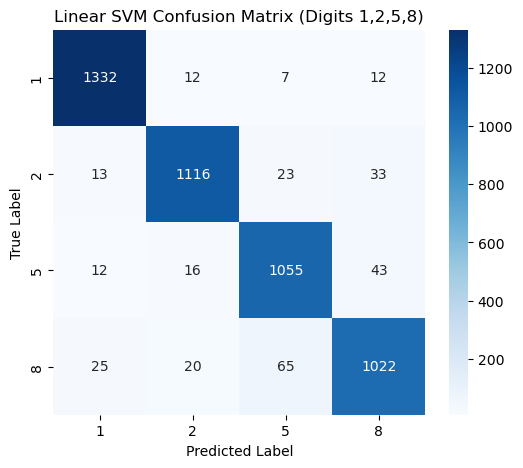

In [24]:
# P3_Q4
from sklearn.svm import LinearSVC
digits_q4 = [1, 2, 5, 8]

# Training
mask_train_q4 = np.isin(y_train_full, digits_q4)
X_train_q4 = X_train_full[mask_train_q4]
y_train_q4 = y_train_full[mask_train_q4]

# Test
mask_test_q4 = np.isin(y_test_full, digits_q4)
X_test_q4 = X_test_full[mask_test_q4]
y_test_q4 = y_test_full[mask_test_q4]

print(f"Training samples: {X_train_q4.shape[0]}")
print(f"Test samples: {X_test_q4.shape[0]}")

# Feature scaling
scaler_q4 = StandardScaler()
X_train_q4_scaled = scaler_q4.fit_transform(X_train_q4)
X_test_q4_scaled = scaler_q4.transform(X_test_q4)

# we have already know the best C from previous experiments
param_grid_q4 = {'C': [10, 100]}

# svm_linear_q4 = SVC(kernel='linear', random_state=3042)
svm_linear_q4 = LinearSVC(C=1.0, random_state=3042, max_iter=20000, tol=1e-4)

# 5-fold stratified CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=3042)

start_time = time.time()
grid_search_q4 = GridSearchCV(
    svm_linear_q4, param_grid_q4, cv=skf, scoring='accuracy', n_jobs=-1
)
grid_search_q4.fit(X_train_q4_scaled, y_train_q4)
train_time_q4 = time.time() - start_time

# Predict on test set
y_pred_q4 = grid_search_q4.predict(X_test_q4_scaled)
test_acc_q4 = accuracy_score(y_test_q4, y_pred_q4)
test_error_q4 = 1 - test_acc_q4

print(f"\nBest C: {grid_search_q4.best_params_['C']}")
print(f"Best CV accuracy: {grid_search_q4.best_score_:.4f}")
print(f"Test misclassification error: {test_error_q4:.4f}")
print(f"Training time: {train_time_q4:.2f} seconds")

# Confusion Matrix
cm_q4 = confusion_matrix(y_test_q4, y_pred_q4)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_q4, 
    annot=True, 
    fmt='d', 
    xticklabels=digits_q4, 
    yticklabels=digits_q4,
    cmap='Blues'
)
plt.title('Linear SVM Confusion Matrix (Digits 1,2,5,8)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Reduced from 144 to 86 features
Best params: {'C': 10, 'gamma': 0.01}
Best CV accuracy: 0.9601
Test misclassification error: 0.0343
Training time: 68.67 seconds


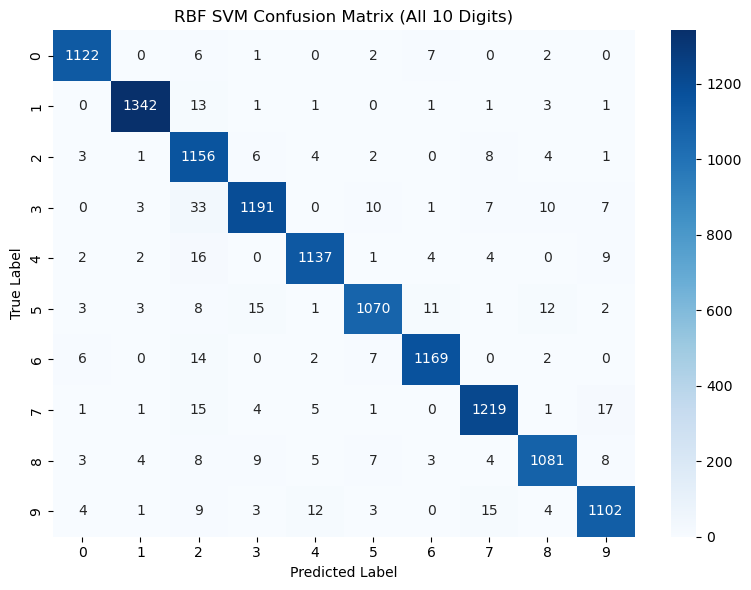

In [22]:
# P3_Q5
from sklearn.decomposition import PCA

# Standardize first
scaler_full = StandardScaler()
X_train_scaled = scaler_full.fit_transform(X_train_full)
X_test_scaled = scaler_full.transform(X_test_full)

# Apply PCA: keep 95% variance (~50-70 components)
pca = PCA(n_components=0.95, random_state=3042)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Reduced from {X_train_full.shape[1]} to {X_train_pca.shape[1]} features")

param_grid_final = {
    'C': [10, 100],
    'gamma': [0.001, 0.01]
}

svm_final = SVC(kernel='rbf', random_state=3042)
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=3042)  # 3-fold to save time

# Use 3-fold CV instead of 5-fold (faster, similar result)
grid_final = GridSearchCV(svm_final, param_grid_final, cv=skf, scoring='accuracy', n_jobs=-1)

start = time.time()
grid_final.fit(X_train_pca, y_train_full)
train_time_final = time.time() - start

# Test
y_pred_final = grid_final.predict(X_test_pca)
test_error_final = 1 - accuracy_score(y_test_full, y_pred_final)

print(f"Best params: {grid_final.best_params_}")
print(f"Best CV accuracy: {grid_final.best_score_:.4f}")
print(f"Test misclassification error: {test_error_final:.4f}")
print(f"Training time: {train_time_final:.2f} seconds")

# Compute confusion matrix
cm_final = confusion_matrix(y_test_full, y_pred_final)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_final,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=np.arange(10),
    yticklabels=np.arange(10)
)
plt.title('RBF SVM Confusion Matrix (All 10 Digits)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


### **P3_Q5: Full 10-Class MNIST Classification**

We trained an **RBF kernel SVM** on the full MNIST dataset (digits 0–9) with the following pipeline:
- Standardized pixel values using `StandardScaler`
- Applied **PCA** to retain 95% of variance (reduced from 144 to **{X_train_pca.shape[1]}** features)
- Used **3-fold stratified cross-validation** to tune hyperparameters `C` and `gamma`
- Selected best model based on cross-validation accuracy

#### **Results**

| Metric                     | Value |
|---------------------------|-------|
| **Model**                 | RBF Kernel SVM with PCA |
| **Best Parameters**       | {'C': 10, 'gamma': 0.01}|
| **Test Misclassification Error** | **{test_error_final:0.0343}** |
| **Training Time**         | **{train_time_final:.2f} 68.67 seconds** |